# 전처리

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv(r'C:\Users\컴퓨터\Documents\[부캠][basic] 심화프로젝트\2025_Airbnb_NYC_listings.csv') #----- 자기 경로 설정!!

# 데이터 전처리 (승근)
## 31 ~ 37번 칼럼 
#### ============================================================
#### 31 ~ 37 주요 컬럼 설명
#### ============================================================
#### • review_scores_location                           : 위치 평점
#### • review_scores_value                              : 가성비 평점
#### • calculated_host_listings_count                   : 호스트 숙소 수(계산값)
#### • calculated_host_listings_count_entire_homes      : 전체 숙소 수
#### • calculated_host_listings_count_private_rooms     : 개인실 수
#### • calculated_host_listings_count_shared_rooms      : 공유실 수
#### • reviews_per_month                                : 월 평균 리뷰 수

-----------------------

## 이번 프로젝트에 사용할 데이터프레임 만들기

In [3]:
cols = [
    'id','name','description','host_id','host_since','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','neighbourhood_cleansed',
    'neighbourhood_group_cleansed','latitude','longitude','property_type','room_type','accommodates','bedrooms','beds','amenities','price','availability_365',
    'number_of_reviews','number_of_reviews_ltm','estimated_occupancy_l365d','estimated_revenue_l365d','review_scores_rating','review_scores_accuracy','review_scores_cleanliness',
    'review_scores_checkin','review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms','calculated_host_listings_count_shared_rooms', 'reviews_per_month'
]
df_sg = df[cols]

In [4]:
df_sg.shape

(22308, 37)

## 31번 컬럼 'review_scores_location'에 의한 전처리

In [112]:
df_sg_cleaned = df_sg.copy()

In [113]:
mask = (df_sg_cleaned['review_scores_location'].isna()) & (df_sg_cleaned['review_scores_accuracy'].notna())
df_sg_cleaned.loc[mask, 'review_scores_location'] = 5.0

In [114]:
df_sg_cleaned.loc[(df['review_scores_location'].isna()) & (df['review_scores_accuracy'].notna()),'review_scores_location']

10849    5.0
Name: review_scores_location, dtype: float64

In [115]:
df_sg_cleaned.shape

(22308, 37)

---------------

# 나만으 연습장 (볼 필요 X)

In [9]:
df_host = df[['host_id','host_name','host_since','host_location','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','host_listings_count','host_identity_verified']]
df_host

,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified
0,62165,Michael,2009-12-11,"New York, NY",NaN,NaN,NaN,f,1.0,t
1,157798,Irene,2010-07-04,"New York, NY",NaN,NaN,100%,f,1.0,t
2,165789,Sarah,2010-07-13,"New York, NY",within a few hours,100%,40%,f,1.0,t
3,166532,Matthew,2010-07-14,"New York, NY",within an hour,100%,97%,t,1.0,t
4,168525,Gustavo,2010-07-16,"New York, NY",within an hour,100%,100%,t,2.0,t
...,...,...,...,...,...,...,...,...,...,...
22303,40019013,Cecilia,2015-07-30,"New York, NY",NaN,NaN,NaN,f,1.0,t
22304,483056418,Kristina,2022-10-10,"New York, NY",within an hour,100%,80%,t,24.0,t
22305,30283594,Global Luxury Suites,2015-03-30,"Hawthorne, NJ",within an hour,94%,99%,f,619.0,t
22306,407304997,Boomerang,2021-06-15,"New York, NY",within an hour,89%,100%,f,26.0,t


In [10]:
df_lct = df[['neighbourhood','neighbourhood_group_cleansed','latitude','longitude']]
df_lct

,neighbourhood,neighbourhood_group_cleansed,latitude,longitude
0,Neighborhood highlights,Brooklyn,40.673760,-73.966110
1,Neighborhood highlights,Manhattan,40.792454,-73.940742
2,Neighborhood highlights,Brooklyn,40.684420,-73.980680
3,Neighborhood highlights,Manhattan,40.818058,-73.946671
4,Neighborhood highlights,Brooklyn,40.710651,-73.950874
...,...,...,...,...
22303,NaN,Manhattan,40.813794,-73.952399
22304,NaN,Brooklyn,40.685500,-73.919510
22305,NaN,Manhattan,40.745290,-73.979380
22306,NaN,Manhattan,40.757133,-73.983124


In [11]:
df_info = df[['property_type','room_type','accommodates','bedrooms','beds','bathrooms','amenities']]
df_info

,property_type,room_type,accommodates,bedrooms,beds,bathrooms,amenities
0,Private room in rental unit,Private room,1,1.0,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif..."
1,Private room in condo,Private room,2,1.0,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",..."
2,Private room in home,Private room,2,5.0,5.0,2.5,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir..."
3,Entire home,Entire home/apt,2,1.0,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close..."
4,Private room in rental unit,Private room,2,1.0,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L..."
...,...,...,...,...,...,...,...
22303,Private room in rental unit,Private room,1,1.0,1.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ..."
22304,Private room in rental unit,Private room,2,1.0,0.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ..."
22305,Entire rental unit,Entire home/apt,5,2.0,3.0,2.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ..."
22306,Entire rental unit,Entire home/apt,4,2.0,2.0,1.0,"[""Oven"", ""Gym"", ""Blender"", ""Dedicated workspac..."


In [12]:
df_price = df[['price','minimum_nights','maximum_nights','availability_365','instant_bookable']]
df_price

,price,minimum_nights,maximum_nights,availability_365,instant_bookable
0,$200.00,90,365,362,f
1,$82.00,30,999,204,f
2,$765.00,3,60,326,f
3,$139.00,2,45,25,f
4,$130.00,4,45,38,f
...,...,...,...,...,...
22303,$72.00,30,365,358,f
22304,$58.00,30,365,363,f
22305,$299.00,30,365,99,f
22306,$200.00,30,365,365,t


In [13]:
df_review = df[['number_of_reviews','reviews_per_month','review_scores_rating','review_scores_cleanliness','review_scores_communication','first_review','last_review']]
df_review

,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,first_review,last_review
0,9,0.05,4.88,4.80,5.00,2010-12-11,2013-05-10
1,102,0.58,4.77,4.76,4.90,2010-10-04,2023-12-09
2,43,0.28,4.70,4.52,4.88,2012-07-09,2023-08-30
3,241,1.36,4.85,4.50,4.96,2010-08-28,2025-02-21
4,274,1.54,4.82,4.61,4.88,2010-08-02,2025-01-03
...,...,...,...,...,...,...,...
22303,0,NaN,NaN,NaN,NaN,NaN,NaN
22304,0,NaN,NaN,NaN,NaN,NaN,NaN
22305,0,NaN,NaN,NaN,NaN,NaN,NaN
22306,0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_notion = df[['host_id','host_name','host_since','host_location','host_response_time','host_response_rate','host_acceptance_rate','host_is_superhost','host_listings_count','host_identity_verified',
                'neighbourhood','neighbourhood_group_cleansed','latitude','longitude',
                'property_type','room_type','accommodates','bedrooms','beds','bathrooms','amenities',
                'price','minimum_nights','maximum_nights','availability_365','instant_bookable',
                'number_of_reviews','reviews_per_month','review_scores_rating','review_scores_cleanliness','review_scores_communication','first_review','last_review']]
df_notion

,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified,...,maximum_nights,availability_365,instant_bookable,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,first_review,last_review
0,62165,Michael,2009-12-11,"New York, NY",NaN,NaN,NaN,f,1.0,t,...,365,362,f,9,0.05,4.88,4.80,5.00,2010-12-11,2013-05-10
1,157798,Irene,2010-07-04,"New York, NY",NaN,NaN,100%,f,1.0,t,...,999,204,f,102,0.58,4.77,4.76,4.90,2010-10-04,2023-12-09
2,165789,Sarah,2010-07-13,"New York, NY",within a few hours,100%,40%,f,1.0,t,...,60,326,f,43,0.28,4.70,4.52,4.88,2012-07-09,2023-08-30
3,166532,Matthew,2010-07-14,"New York, NY",within an hour,100%,97%,t,1.0,t,...,45,25,f,241,1.36,4.85,4.50,4.96,2010-08-28,2025-02-21
4,168525,Gustavo,2010-07-16,"New York, NY",within an hour,100%,100%,t,2.0,t,...,45,38,f,274,1.54,4.82,4.61,4.88,2010-08-02,2025-01-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22303,40019013,Cecilia,2015-07-30,"New York, NY",NaN,NaN,NaN,f,1.0,t,...,365,358,f,0,NaN,NaN,NaN,NaN,NaN,NaN
22304,483056418,Kristina,2022-10-10,"New York, NY",within an hour,100%,80%,t,24.0,t,...,365,363,f,0,NaN,NaN,NaN,NaN,NaN,NaN
22305,30283594,Global Luxury Suites,2015-03-30,"Hawthorne, NJ",within an hour,94%,99%,f,619.0,t,...,365,99,f,0,NaN,NaN,NaN,NaN,NaN,NaN
22306,407304997,Boomerang,2021-06-15,"New York, NY",within an hour,89%,100%,f,26.0,t,...,365,365,t,0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_notion.head()

,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified,...,maximum_nights,availability_365,instant_bookable,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_communication,first_review,last_review
0,62165,Michael,2009-12-11,"New York, NY",NaN,NaN,NaN,f,1.0,t,...,365,362,f,9,0.05,4.88,4.80,5.00,2010-12-11,2013-05-10
1,157798,Irene,2010-07-04,"New York, NY",NaN,NaN,100%,f,1.0,t,...,999,204,f,102,0.58,4.77,4.76,4.90,2010-10-04,2023-12-09
2,165789,Sarah,2010-07-13,"New York, NY",within a few hours,100%,40%,f,1.0,t,...,60,326,f,43,0.28,4.70,4.52,4.88,2012-07-09,2023-08-30
3,166532,Matthew,2010-07-14,"New York, NY",within an hour,100%,97%,t,1.0,t,...,45,25,f,241,1.36,4.85,4.50,4.96,2010-08-28,2025-02-21
4,168525,Gustavo,2010-07-16,"New York, NY",within an hour,100%,100%,t,2.0,t,...,45,38,f,274,1.54,4.82,4.61,4.88,2010-08-02,2025-01-03


In [16]:
df_notion.head(7).T

,0,1,2,3,4,5,6
host_id,62165,157798,165789,166532,168525,169927,15991
host_name,Michael,Irene,Sarah,Matthew,Gustavo,Hubert,Allen & Irina
host_since,2009-12-11,2010-07-04,2010-07-13,2010-07-14,2010-07-16,2010-07-17,2009-05-06
host_location,"New York, NY","New York, NY","New York, NY","New York, NY","New York, NY","Saint-Aubin-sur-Scie, France","New York, NY"
host_response_time,NaN,NaN,within a few hours,within an hour,within an hour,NaN,within an hour
host_response_rate,NaN,NaN,100%,100%,100%,NaN,100%
host_acceptance_rate,NaN,100%,40%,97%,100%,NaN,100%
host_is_superhost,f,f,f,t,t,f,t
host_listings_count,1.0,1.0,1.0,1.0,2.0,2.0,1.0
host_identity_verified,t,t,t,t,t,t,t


In [17]:
df_super = df.loc[df['host_is_superhost'] == 't']
df_normal = df.loc[df['host_is_superhost'] == 'f']

In [18]:
df_normal['review_scores_rating'].mean()

np.float64(4.652157002858309)

In [19]:
df_super['host_listings_count'].mean()


np.float64(22.42323380649372)

## TOP 10 amenities 출력

In [20]:
import ast
from collections import Counter

# 1. 문자열(String) 형태를 진짜 리스트(List)로 변환
# 데이터가 "['Wifi', 'Heating']" 처럼 따옴표까지 포함된 글자라면 이 과정이 꼭 필요!!
df['amenities'] = df['amenities'].apply(ast.literal_eval)

# 2. 리스트를 개별 행으로 펼치기 (Explode)
# 한 칸에 들어있던 [A, B, C]를 각각 3개의 행(A / B / C)으로 쪼개줍니다.
exploded_amenities = df['amenities'].explode()

# 3. 개수 세고 상위 10개 추출
top_10_amenities = exploded_amenities.value_counts().head(10)

In [21]:
top_10_amenities

amenities
Smoke alarm              21096
Wifi                     20577
Carbon monoxide alarm    19386
Kitchen                  19122
Hot water                17333
Essentials               16548
Hangers                  16524
Hair dryer               15354
Iron                     15268
Air conditioning         14922
Name: count, dtype: int64

In [22]:
exploded_amenities

0                 Refrigerator
0        Dishes and silverware
0                         Wifi
0                      Kitchen
0                     Elevator
                 ...          
22307                   Washer
22307                     Wifi
22307              Smoke alarm
22307                  Kitchen
22307                       TV
Name: amenities, Length: 684508, dtype: str

In [23]:
df['amenities']

0        [Refrigerator, Dishes and silverware, Wifi, Ki...
1        [Oven, Blender, Luggage dropoff allowed, Dedic...
2        [Portable fans, Oven, Baking sheet, Fire extin...
3        [Fire extinguisher, Clothing storage: closet, ...
4        [Oven, Rice maker, Laundromat nearby, Luggage ...
                               ...                        
22303    [Air conditioning, Carbon monoxide alarm, Wifi...
22304    [Air conditioning, Carbon monoxide alarm, Wash...
22305    [Air conditioning, Carbon monoxide alarm, Wash...
22306    [Oven, Gym, Blender, Dedicated workspace, Dini...
22307    [Air conditioning, Carbon monoxide alarm, Wash...
Name: amenities, Length: 22308, dtype: object

In [24]:
acco_data = df_info['accommodates']
q_1 = np.percentile(acco_data, q=25)

<Axes: ylabel='accommodates'>

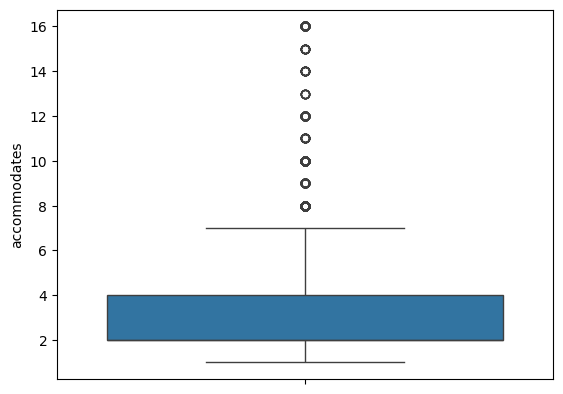

In [25]:
sns.boxplot(data=acco_data)

## 슈호 일호 비교
- price
- 리뷰 수
- 전반적 평점
- 추정치는 거의 다
- name, description, neighborhood_overview
- host_response_rate
- host_acceptance_rate
- (host_is_superhost)
- neighbourhood_cleansed
- neighbourhood_group_cleansed
- room type
- availability_365(number_of_reviews_ltm)
- number_of_reviews_ly (=전년도 리뷰 수)
- (estimated_occupancy_l365d)
- review_scores_rating
- review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location ,review_scores_value
- reviews_per_month

## 전처리 아이디어
- host_total_listings_count
- calendar_last_scraped --> 3/3은 왜 날리지 않았는지 발표에 포함하면 좋을 듯
- 

In [26]:
cols = list(df_host.columns) + ['host_listings_count', 'host_total_listings_count', 'calculated_host_listings_count']
df.loc[df['host_id'].duplicated(), cols].sort_values('host_id').head(10)

,host_id,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_identity_verified,host_listings_count,host_total_listings_count,calculated_host_listings_count
1807,2787,John,2008-09-07,"New York, NY",within an hour,100%,83%,f,4.0,t,4.0,13.0,4
1814,2787,John,2008-09-07,"New York, NY",within an hour,100%,83%,f,4.0,t,4.0,13.0,4
1848,2787,John,2008-09-07,"New York, NY",within an hour,100%,83%,f,4.0,t,4.0,13.0,4
7118,2845,Jennifer,2008-09-09,"Woodstock, NY",within a day,71%,18%,f,7.0,t,7.0,9.0,3
8372,4396,Casey,2008-11-19,"New York, NY",within an hour,100%,92%,t,3.0,t,3.0,4.0,2
1989,11481,Annette,2009-03-26,"New York, NY",a few days or more,40%,17%,f,6.0,t,6.0,13.0,4
15136,11481,Annette,2009-03-26,"New York, NY",a few days or more,40%,17%,f,6.0,t,6.0,13.0,4
64,11481,Annette,2009-03-26,"New York, NY",a few days or more,40%,17%,f,6.0,t,6.0,13.0,4
2121,15523,Vadim,2009-05-01,"New York, NY",a few days or more,25%,0%,f,2.0,t,2.0,2.0,2
3997,16104,Kahshanna,2009-05-07,"New York, NY",within an hour,100%,33%,f,2.0,f,2.0,2.0,2


In [27]:
# 1. 호스트별로 실제 데이터가 몇 줄 있는지 세기
actual_counts = df.groupby('host_id').size()
actual_counts

host_id
1678         1
2234         1
2571         1
2787         4
2845         2
            ..
680154409    1
680454869    1
680980208    1
681365613    1
681436540    4
Length: 10934, dtype: int64

In [28]:
# 2. 데이터프레임에 기록된 값과 비교 (첫 번째 값 기준)
reported_counts = df.groupby('host_id')['calculated_host_listings_count'].first()
reported_counts

host_id
1678         1
2234         1
2571         1
2787         4
2845         3
            ..
680154409    1
680454869    1
680980208    1
681365613    1
681436540    4
Name: calculated_host_listings_count, Length: 10934, dtype: int64

In [29]:
# 3. 일치하는지 확인
comparison = (actual_counts == reported_counts)
print(comparison.value_counts()) # True가 많다면 데이터가 일치하는 것!

True     10141
False      793
Name: count, dtype: int64


In [30]:
df['calculated_host_listings_count'].value_counts(dropna=False).head(15)

calculated_host_listings_count
1       7967
2       2772
3       1532
1194    1094
4        963
5        540
6        538
8        370
7        370
330      310
9        293
298      291
10       280
236      228
242      197
Name: count, dtype: int64

In [31]:
df['host_verifications'].isna().sum()

np.int64(20)

In [32]:
df['calculated_host_listings_count']

0         1
1         1
2         1
3         1
4         2
         ..
22303     1
22304    24
22305    48
22306    25
22307    24
Name: calculated_host_listings_count, Length: 22308, dtype: int64

In [33]:
df.loc[df['accommodates'] == 15]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
3466,10549,24699301,city scrape,Modern 4BR/2BA Train@900ft/NYC30mn by nycHubHomes,Fresh and clean apartment in a private house ...,One of a kind diverse melting pot neighborhood...,20912691,Jeff,2014-09-03,"New York, NY",...,4.88,4.64,4.70,NaN,f,5,5,0,0,0.61
4160,12271,30565107,city scrape,"7 train MainSt.Flushing Walk to Citifield, US ...",Quiet place but close to Main Street Actions,Close to Roosevelt Ave & Main Street Restauran...,110058188,Charles,2017-01-05,"New York, United States",...,4.62,4.69,4.56,NaN,f,1,0,1,0,1.24
4244,12471,31290477,city scrape,"Spacious Studio Loft, East Williamsburg",The Studio is located in the East Williamsburg...,Native Creations is convienently located near ...,231691559,Jeanette,2018-12-20,"New York, United States",...,5.00,4.96,4.74,NaN,f,1,1,0,0,0.31
6095,16584,44648831,city scrape,"Large 4 bedrooms 2 baths, Balcony up to 15 people","Nice 4 Bedrooms , 2 Baths, Balcony apartment i...",Beautiful neighborhood with everything you nee...,183178516,Lucky Day Realty Corp.,2018-04-08,"New York, IA",...,NaN,NaN,NaN,NaN,f,9,8,1,0,NaN
8383,20229,53192744,city scrape,Lux Xcape1 3BR/2BA;subway@600 steps by nycHubH...,Welcome to The Devonshire / LVL1 in Jamaica Es...,"Comfort, peace, and tranquility in the timber-...",430352020,Katherine,2021-11-04,"New York, NY",...,5.00,4.92,5.00,NaN,f,3,3,0,0,0.34
11112,23996,726074123553985535,city scrape,Best Place to Stay in NYC! 3 Convenient Units,This modern property in Manhattan is just step...,Empire State Building - 0.1 miles <br />Bryant...,25138314,RoomPicks By Antony,2014-12-23,NaN,...,NaN,NaN,NaN,OSE-STRREG-0000068,t,70,0,0,0,NaN
12969,26401,842270334846674618,city scrape,Save on 2Day+ Stays|6Br Triplex,Our stunning 6 br Triplex is in the heart of S...,Welcome to our 3 charming apartments located i...,481452777,Jude,2022-09-28,NaN,...,5.00,4.75,5.00,Exempt,f,15,15,0,0,0.35
14046,27813,903068061959225269,city scrape,107Studio Events/Theater/Karaoke,This memorable place is anything but ordinary.,NaN,357523705,Sheneca,2020-07-20,"New Rochelle, NY",...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.05
15415,29483,990723645034323101,city scrape,Beautiful spacious home + patio,you will be in the central of Brooklyn The bes...,"Crown heights historic district, one of the mo...",391579286,Avraham,2021-03-07,"New York, NY",...,4.94,4.58,4.88,Exempt,t,6,6,0,0,2.13
15606,29720,1004956180920728506,city scrape,3-Bedroom Apartment-t,This is a large stylish & comfortable home loc...,NaN,465866457,Wei,2022-06-24,NaN,...,4.00,4.00,5.00,NaN,f,12,11,1,0,0.08


In [34]:
df['price'] = df['price'].str.replace('$','',regex=False).str.replace(',','',regex=False)

In [35]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [36]:
df['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
22303     72.0
22304     58.0
22305    299.0
22306    200.0
22307     58.0
Name: price, Length: 22308, dtype: float64

<Axes: ylabel='price'>

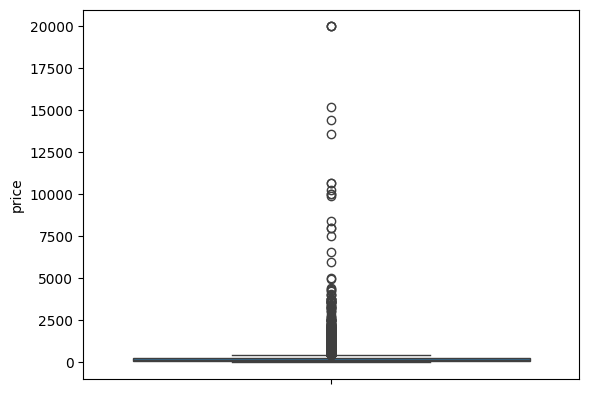

In [37]:
hlc_data = df['price']
sns.boxplot(data=hlc_data)


In [38]:
df['price'].describe()

count    22308.000000
mean       213.835216
std        427.599435
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

In [39]:
df.loc[df['price']==7]

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
15556,29663,993740332378198800,city scrape,Affordable Private Room Manhattan | Blue Echo,Please read carefully before booking!<br /><br...,NaN,243489304,Jack,2019-02-16,"New York, NY",...,4.86,4.57,4.38,Exempt,f,7,0,7,0,3.73


<Axes: xlabel='price', ylabel='Count'>

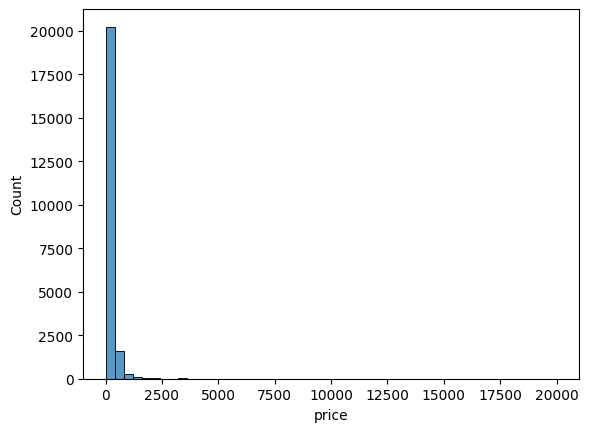

In [40]:
sns.histplot(df['price'], bins=50)

In [41]:
df['neighborhood_overview']

0        Full of tree-lined streets and beautiful brown...
1         Manhattan, SE corner of 2nd Ave/ E. 110th street
2        diverse, lively, hip, cool: loaded with restau...
3        West Harlem is now packed with great restauran...
4        THE NEIGHBORHOOD:<br />Our apartment is locate...
                               ...                        
22303                                                  NaN
22304                                                  NaN
22305                                                  NaN
22306                                                  NaN
22307                                                  NaN
Name: neighborhood_overview, Length: 22308, dtype: str

In [42]:
df.loc[df['host_is_superhost']=='t', 'host_acceptance_rate'].value_counts(dropna=False)

host_acceptance_rate
100%    1975
99%      441
91%      244
96%      189
98%      187
        ... 
16%        1
24%        1
30%        1
22%        1
0%         1
Name: count, Length: 84, dtype: int64

In [43]:
df.loc[df['host_is_superhost']=='t'].shape

(6135, 73)

In [44]:
df['estimated_occupancy_l365d'].describe()

count    22308.000000
mean        71.562713
std         96.622429
min          0.000000
25%          0.000000
50%          0.000000
75%        120.000000
max        255.000000
Name: estimated_occupancy_l365d, dtype: float64

In [45]:
df['estimated_revenue_l365d'].describe()

count    2.230800e+04
mean     1.190194e+04
std      2.418692e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.650000e+04
max      1.020050e+06
Name: estimated_revenue_l365d, dtype: float64

In [46]:
df.loc[(df['review_scores_location'].isna()) & (df['review_scores_accuracy'].notna()),['review_scores_rating','review_scores_accuracy','review_scores_cleanliness','review_scores_checkin','review_scores_communication','review_scores_location','review_scores_value']]

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
10849,5.0,5.0,5.0,5.0,5.0,NaN,5.0


In [47]:
df['host_response_rate'] = df['host_response_rate'].str.replace('%','',regex=False).str.replace(',','',regex=False)
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')

In [48]:
df['host_response_rate']

0          NaN
1          NaN
2        100.0
3        100.0
4        100.0
         ...  
22303      NaN
22304    100.0
22305     94.0
22306     89.0
22307    100.0
Name: host_response_rate, Length: 22308, dtype: float64

In [49]:
df.loc[(df['host_is_superhost']=='t') & (df['host_response_rate'] <= 89),'host_response_rate'].count()

np.int64(168)

In [50]:
df.loc[df['host_is_superhost']=='t', 'host_is_superhost'].count()

np.int64(6135)

In [51]:
df['host_response_rate'].value_counts(dropna=False)

host_response_rate
100.0    12885
NaN       4393
99.0       727
98.0       562
0.0        436
         ...  
16.0         1
43.0         1
55.0         1
11.0         1
62.0         1
Name: count, Length: 66, dtype: int64

In [85]:
df['host_location'].isna().sum()

np.int64(5283)

In [88]:
df_sg_cleaned.loc[df['bedrooms'].isna(), ['room_type']]

,room_type
23,Entire home/apt
68,Entire home/apt
304,Entire home/apt
5335,Entire home/apt
5557,Private room
5775,Private room
5947,Entire home/apt
5948,Private room
6679,Private room
7600,Entire home/apt


In [118]:
df['price'].describe()

count    22308.000000
mean       213.835216
std        427.599435
min          7.000000
25%         85.000000
50%        140.000000
75%        240.000000
max      20000.000000
Name: price, dtype: float64

<Axes: >

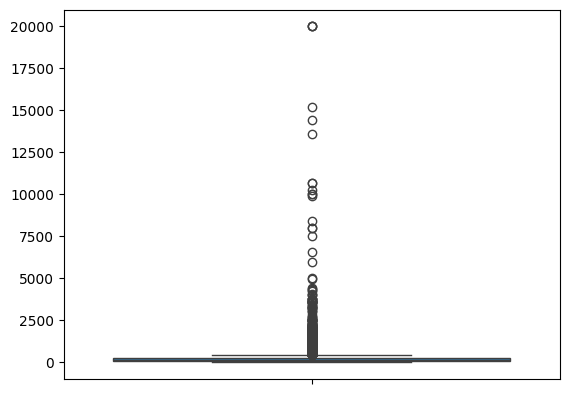

In [ ]:
data = df['price'].dropna().values
q_1 = np.percentile(df['price'], q=25)
q_3 = np.percentile(df['price'], q=75)

iqr = q_3 - q_1
sns.boxplot(data=data)

<Axes: ylabel='Count'>

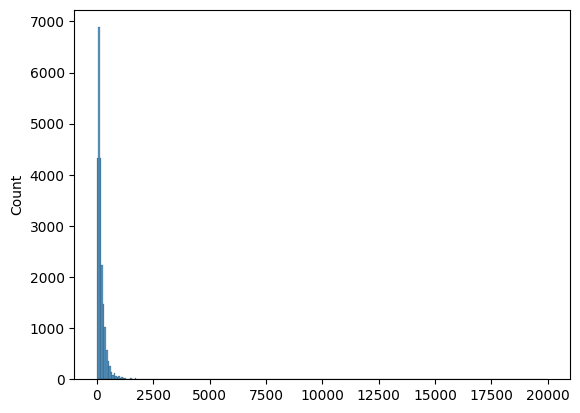

In [123]:
sns.histplot(data=data)